A notebook to look at the fraction of cells tuned to different variables (escape, speed, dist_to_shelter) in the escape pattern

In [188]:
%load_ext autoreload
%autoreload 2
from behave_analysis.process.process import Process
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from settings.settings_analyze_efizz import Settings_ae
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_tuning_stat
from behave_analysis.analyze.EscapePattern.ComputeEscapeTuning import ComputeEscapeTuning
from databank import full_experiments_objects as experiments_objects

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF
conditions = ["shelter_only", "barrier", "flipped_barrier"]
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [190]:
# the settings of the analysis that we want to plot!
settings = {'ep_bins': 25,
            'ep_no_stationary': False,
            'ep_interpolation_mult': 2,
            'ep_gaussian_fitting': False,
            'ep_compute_loo_reliability': False,
            'ep_tuned_compare_method': 'euclidean',
            'ep_tuned_stats': 'bootstrap',
            'ep_tuned_stats_samples': 100,
            'linshift_min_step': 120,
            'linshift_step': 80,
            'linshift_step_n': 100,
            'stim_type': 'audio',
            'cluster_type': 'good',
            'cluster_labels': 'bombcell',
            'condition_types': 'experimental_conditions',
            'compartment_split': ['all']}
Settings_ae = settings_overrides(Settings_ae, {'redo_compute': False})

colors = [
    "#4363d8",  # Medium blue - different from your blues
    "#C77CFF",   # Light purple - distinct from your darker purple
    "#dcbf46"   # Gold/mustard - not used in your palette
]

The next two cells make bar plots for how many cells are significantly tuned to a given variable... scroll down for plotting residuals!

In [191]:
"""This sia random cell that needs to go """
e = experiments_objects[0]
session = Process(e).load_session()
tuning = "frac_route in homing&escape"
computeET = ComputeEscapeTuning(tuning = tuning, session=session, settings=Settings_ae, aefizz=None)
data = computeET.load_results()
stat = 'zscore_peak'
real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                            shifted_matrix=data['fr_shift'], 
                                            shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                            neural_matrix=data['neural_matrix'], 
                                            condition=data['condition_vector'])
sig_escape = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
tuning = 'residual: frac_route in homing&escape - speed in explore'
computeET = ComputeEscapeTuning(tuning = tuning, session=session, settings=Settings_ae, aefizz=None)
data_residual = computeET.load_results()
real_stat_residual, shift_stat_residual = compute_tuning_stat(stat=stat, 
                                            shifted_matrix=data_residual['fr_shift'], 
                                            shift0=int(np.shape(data_residual['fr_shift'])[0] / 2), 
                                            neural_matrix=data_residual['neural_matrix'], 
                                            condition=data_residual['condition_vector'])
sig_escape_residual = real_stat_residual > np.nanpercentile(shift_stat_residual, 95, axis=0)

2026-09-11 13:36:23.027 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 13:36:23.042 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['287a2a6a19104af2' 'c847382f601b458e' 'cdd666166db941aa'
 '88134a1b1fb1428b' '09b804d3579245dd' 'eec098426b1b4bfe'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_baseline_2023_08_17T13_41_44\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 13:36:23.376 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to residual: frac_route in homing&escape - speed in explore in EP tuning database...
2026-09-11 13:36:23.406 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 2 matched results in database: ['cf8f8d8dbc884cf7' 'ae068fd6305947b5'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_baseline_2023_08_17T13_41_44\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


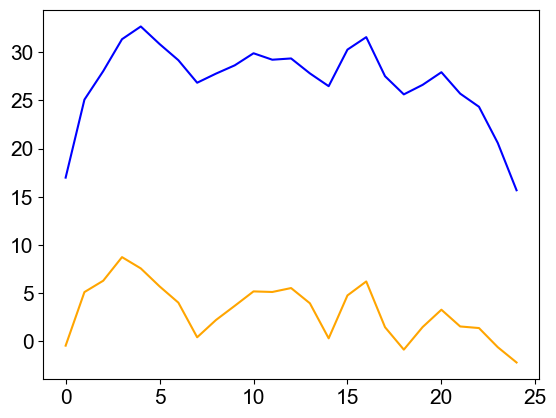

In [123]:
"""This one also needs to go"""
c = 1
sig = np.where(~sig_escape_residual[c, :] & sig_escape[c, :])[0]
n = 18
plt.plot(data["fr_full"][c, sig[n]], color = "blue")
plt.plot(data_residual["fr_full"][c, sig[n]], color = "orange")
if sig_escape_residual[c, sig[n]] and sig_escape[c, sig[n]]:
    plt.title("neuron {} is significant in both".format(sig[n]))

In [227]:
tuning = "frac_route in homing&escape" # edit to change the variable to plot
# tuning = "speed in explore" # edit to change the variable to plot

stat = 'zscore_peak' # edit to change the tuning statistic to plot (options: 'peak', 'peak_to_mean', 'zscore_peak')
fraction_sig_session = {} #np.zeros((len(experiments_objects), 3))

for i, e in enumerate(experiments_objects):
    session = Process(e).load_session()
    data_path = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning")
    computeET = ComputeEscapeTuning(tuning = tuning, session=session, settings=Settings_ae, aefizz=None)

    if computeET.do_analysis:
        print("analysis not done yet for this session {0}! Sad".format(session['name']))
        continue

    if computeET.database[computeET.database["name"] == computeET.hexaname]["insufficient_data"].values[0]:
        print("insufficient data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
        continue

    print("loading data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
    data = computeET.load_results()
    real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                                shifted_matrix=data['fr_shift'], 
                                                shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                                neural_matrix=data['neural_matrix'], 
                                                condition=data['condition_vector'])
    sig_escape = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
    for c_idx, c in enumerate(data["all_conditions"]):
        frac_sig = np.sum(sig_escape[c_idx,:]) / sig_escape.shape[1]
        if np.isnan(real_stat[c_idx,:]).all():
            frac_sig = np.nan
        if c in fraction_sig_session.keys():
            fraction_sig_session[c][i] = frac_sig
        else:
            fraction_sig_session[c] = np.full((len(experiments_objects)), np.nan)
            fraction_sig_session[c][i] = frac_sig

2026-09-11 20:07:05.265 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 20:07:05.283 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['287a2a6a19104af2' 'c847382f601b458e' 'cdd666166db941aa'
 '88134a1b1fb1428b' '09b804d3579245dd' 'eec098426b1b4bfe'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_baseline_2023_08_17T13_41_44\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']
loading data for session Mouse: JAL004, Experiment: shelter, Run number: 0 with hexaname eec098426b1b4bfe


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 20:07:05.513 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 20:07:05.539 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['ce3aad308b9a4d06' '17326fb7ca344f88' '67fc3a4fe9be4ab8'
 '35b148c8182c4289' '47145bbb44934628' 'f059a9089e504f8e'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_mushroom_2023_08_18T08_22_16\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']
loading data for session Mouse: JAL004, Experiment: mushroom, Run number: 1 with hexaname f059a9089e504f8e


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 20:07:05.823 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 20:07:05.892 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 6 matched results in database: ['70846ce8ec784b22' 'e62fe5ff91b94587' '7682ea2384b442eb'
 '4dd0d28dd32b41e9' '5cc41b0006254c48' 'f17117be42694a59'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_08_21T12_53_10\processed_data\models\escape_tuning\EscapePattern_results.csv


...

computing tuning in conditions: ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip', 'barrier_removed']
loading data for session Mouse: JAL008, Experiment: flip, Run number: 4 with hexaname 86c0f1e2fbe8438a


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 20:12:07.954 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 20:12:08.000 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 2 matched results in database: ['69221c7c6efa4538' '7208b8abb4854807'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_barrier_flip_5_2024_05_14T10_18_03\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']
loading data for session Mouse: JAL008, Experiment: flip, Run number: 5 with hexaname 7208b8abb4854807


2026-09-11 20:12:13.280 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 20:12:13.361 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 2 matched results in database: ['b2ac4cb4a1a74b49' '966ed2b562224684'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL008\JAL008_shelter_tiny_flip_2_2024_05_21T11_10_19\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['shelter_only', 'barrier_pre_flip', 'barrier_post_flip']
loading data for session Mouse: JAL008, Experiment: tiny, Run number: 2 with hexaname 966ed2b562224684


Text(0.5, 0.98, 'frac_route in homing&escape')

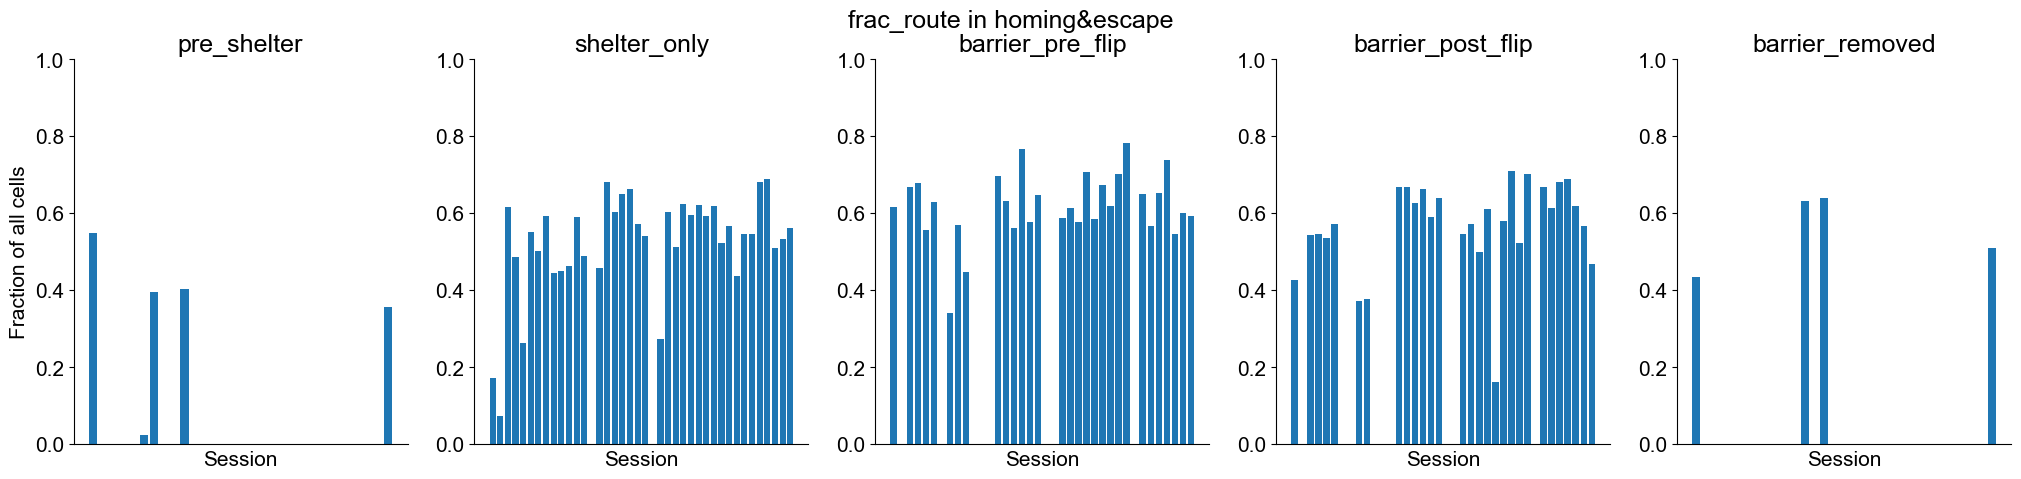

In [228]:
fig, ax = plt.subplots(1, len(fraction_sig_session), figsize=(5 * len(fraction_sig_session), 5))

for c_idx, c in enumerate(list(fraction_sig_session.keys())):
    ax[c_idx].bar(np.arange(fraction_sig_session[c].shape[0]), fraction_sig_session[c])
    ax[c_idx].set_xticks([])
    ax[c_idx].set_xlabel('Session')
    ax[c_idx].set_title(c)
    ax[c_idx].spines['top'].set_visible(False)
    ax[c_idx].spines['right'].set_visible(False)
    ax[c_idx].set_ylim(0, 1)
ax[0].set_ylabel('Fraction of all cells')
fig.suptitle(tuning)

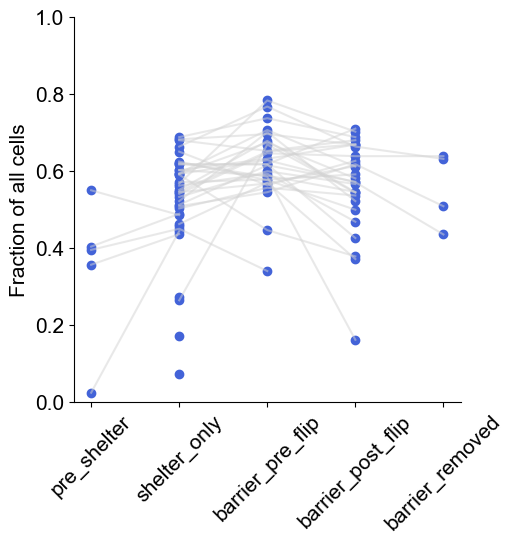

In [229]:
"""Overview plot across sessions as a scatter plot"""
fig, ax = plt.subplots(1, 1, figsize=(len(fraction_sig_session), 5))
# make a matrix of the fraction of significant cells for each condition across sessions
fraction_sig_session_matrix = np.full((len(experiments_objects), len(fraction_sig_session)), np.nan)

for c_idx, c in enumerate(list(fraction_sig_session.keys())):
    fraction_sig_session_matrix[:, c_idx] = fraction_sig_session[c]
    ax.scatter(np.full_like(fraction_sig_session_matrix[:, c_idx], c_idx), fraction_sig_session_matrix[:, c_idx], color = colors[0])
    ax.hlines(np.mean(fraction_sig_session_matrix[:, c_idx]), c_idx - 0.2, c_idx + 0.2, color=colors[0], linewidth=2)
ax.set_xticks(np.arange(len(fraction_sig_session)))
ax.set_xticklabels(list(fraction_sig_session.keys()), rotation=45)
ax.set_ylabel('Fraction of all cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)
    # ax.set_title(tuning)
ax.plot(fraction_sig_session_matrix.T, color = 'lightgrey', alpha = 0.5)

In [30]:
"""A cell to look at some examples of how linear shift breaks the tuning of cells"""
from syd import make_viewer

viewer = make_viewer()
viewer.add_integer("neuron", min = 0, max = sig_escape.shape[1]-1)
viewer.add_integer("condition", min = 0, max = 2)

def plot(state):
    c = state['condition']
    n = state['neuron']
    fig, axs = plt.subplots(1, 3, figsize=(12, 6))

    fr_shifted_no0 = np.delete(data['fr_shift'], int(np.shape(data['fr_shift'])[0] / 2), axis=0)
    ymin = min(np.nanmin(data['fr_full'][c, n, :]), np.nanmin(data['fr_shift'][:, c, n, :]))
    ymax = max(np.nanmax(data['fr_full'][c, n, :]), np.nanmax(data['fr_shift'][:, c, n, :]))

    # subplot 1: original tuning curve
    axs[0].plot(data['fr_full'][c, n, :], 'k', linewidth=2, label='Original FR')
    axs[0].set_ylabel('Firing Rate')
    axs[0].set_title('Original Tuning Curve')
    axs[0].set_ylim(ymin, ymax)

    # subplot 2: shifted tuning curve
    perc95 = np.argmin(shift_stat[:, c, n] - np.percentile(shift_stat[:, c, n], 95))
    # don't plot the shift0 curve
    axs[1].plot(fr_shifted_no0[:, c, n, :].T, 'k', alpha=0.5, linewidth = .5, label='Shifted FR')
    axs[1].plot(data['fr_shift'][perc95, c, n, :], 'k', linewidth=2, label='95th Percentile Shifted FR')
    axs[1].set_title('Shifted Tuning Curves')
    axs[1].set_ylim(ymin, ymax)

    # subplot 3: peak to mean ratio for original and shifted
    axs[2].hist(shift_stat[:, c, n], bins=20, alpha=0.7, label='Shifted Peak-to-Mean')
    axs[2].axvline(real_stat[c, n], color='k', linestyle='--', label='Original Peak-to-Mean')
    axs[2].set_title(stat)
    axs[2].set_ylabel('Number of Shifts')
    axs[2].legend(bbox_to_anchor=(0.5, -.2), loc='upper center')
    axs[2].set_xlabel(stat)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for i in range(2):
        axs[i].set_xticks([0, 12.5, 25])
        if tuning.split(" in ")[0] == "speed":
            axs[i].set_xticklabels([0, 25, 50])
        else:
            # axs[i].set_xticklabels([0, int(data['bin_edges'][-1])/2, int(data['bin_edges'][-1])])
            axs[i].set_xticklabels([0, .5, 1])
        axs[i].set_xlabel(tuning.split(" in ")[0])

    fig.tight_layout()

    return fig

viewer.set_plot(plot)
viewer.show()

The next three cells make bar plots to show fraction of cells tuned to a given variable after regressing out a different variable

In [ ]:
tuning = 'residual: frac_route in homing&escape - speed in explore' # edit to change the variable to plot
res = tuning.split("residual: ")[1]
var = [tuning, res.split(" - ")[0], res.split(" - ")[1]]

fraction_sig_sesh_res = {tuning: {},
                         res.split(" - ")[0]: {},
                         res.split(" - ")[1]: {}}

for i, e in enumerate(experiments_objects):
    session = Process(e).load_session()
    data_path = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning")
    sig = {tuning: [],
            res.split(" - ")[0]: [],
            res.split(" - ")[1]: []}
    for v in var:
        computeET = ComputeEscapeTuning(tuning = v, session=session, settings=Settings_ae, aefizz=None)

        if computeET.do_analysis:
            print("analysis not done yet for this session {0} for variable {1}! Sad".format(session['name'], v))

            continue
        if computeET.database[computeET.database["name"] == computeET.hexaname]["insufficient_data"].values[0]:
            print("insufficient data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
            continue

        print("loading data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
        data = computeET.load_results()
        shift0 = int(np.shape(data['y_fitted_shift'])[0] / 2)
        real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                                    shifted_matrix=data['fr_shift'], 
                                                    shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                                    neural_matrix=data['neural_matrix'], 
                                                    condition=data['condition_vector'])
        s = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
        sig[v] = s#[:5,:]
    usage = [len(sig[v]) for v in sig.keys()]
    if max(usage) == 0:
        continue
    for v in var:
        if v not in sig.keys():
            sig[v] = np.full((sig[list(sig.keys())[0]].shape), False)

    sig_var1 = sig[var[1]] & sig[var[0]] # sig for the first variable (var[1] e.g. escape in homing&escape) after removing residuals (var[0])
    sig_var1_nores = sig[var[1]] & ~sig[var[0]] # sig for the first variable (var[1] e.g. escape in homing&escape) no longer sig after removing activity to second variable (var[2] e.g. bird_dist_shelter in explore)
    sig_var2 = sig[var[2]] & ~sig[var[1]] # sig for the second variable (var[2] e.g. bird_dist_shelter in explore) but not the first (var[1] e.g. escape in homing&escape)
    # NB: these should be completely non-overlapping sets!!
    assert np.sum(sig_var1 & sig_var1_nores) == 0
    assert np.sum(sig_var1 & sig_var2) == 0
    assert np.sum(sig_var1_nores & sig_var2) == 0
    for c_idx, c in enumerate(data["all_conditions"]):
        if c in fraction_sig_sesh_res[var[0]].keys():
            fraction_sig_sesh_res[var[0]][c][i] = np.sum(sig_var1[c_idx,:]) / sig_var1.shape[1]
            fraction_sig_sesh_res[var[1]][c][i] = np.sum(sig_var1_nores[c_idx,:]) / sig_var1_nores.shape[1]
            fraction_sig_sesh_res[var[2]][c][i] = np.sum(sig_var2[c_idx,:]) / sig_var2.shape[1]
        else:
            fraction_sig_sesh_res[var[0]][c] = np.full((len(experiments_objects)), np.nan)
            fraction_sig_sesh_res[var[1]][c] = np.full((len(experiments_objects)), np.nan)
            fraction_sig_sesh_res[var[2]][c] = np.full((len(experiments_objects)), np.nan)
            fraction_sig_sesh_res[var[0]][c][i] = np.sum(sig_var1[c_idx,:]) / sig_var1.shape[1]
            fraction_sig_sesh_res[var[1]][c][i] = np.sum(sig_var1_nores[c_idx,:]) / sig_var1_nores.shape[1]
            fraction_sig_sesh_res[var[2]][c][i] = np.sum(sig_var2[c_idx,:]) / sig_var2.shape[1]


2026-09-11 12:50:48.887 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to residual: frac_route in homing&escape - speed in explore in EP tuning database...
2026-09-11 12:50:48.897 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 1 matched results in database: ['a24088f326044fa2'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_mush1_2023_08_22T13_13_41\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']
loading data for session Mouse: JAL004, Experiment: mushroom, Run number: 2 with hexaname a24088f326044fa2


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 12:50:53.740 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to frac_route in homing&escape in EP tuning database...
2026-09-11 12:50:53.765 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 5 matched results in database: ['cfe1faf5eaf841fe' 'c3fe1b7bb90a4f04' 'd62f0f0c3a184918'
 '1278bbbed4994e3d' 'fdfce5c5e3b8494a'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_mush1_2023_08_22T13_13_41\processed_data\models\escape_tuning\EscapePattern_results.csv


computing tuning in conditions: ['pre_shelter', 'shelter_present']
loading data for session Mouse: JAL004, Experiment: mushroom, Run number: 2 with hexaname fdfce5c5e3b8494a


c:\Users\Jasmine\miniconda3\envs\JAL2pipeline\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
2026-09-11 12:50:56.180 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to speed in explore in EP tuning database...
2026-09-11 12:50:56.224 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscapeTuning:__init__:72 - checking for existing results to residual: frac_route in homing&escape - speed in explore in EP tuning database...
2026-09-11 12:50:56.246 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:24 - Found 1 matched results in database: ['7817d04e43e84edd'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_Habituation_2024_03_01T13_02_08\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-09-11 12:50:56.252 | INFO     | behave_analysis.analyze.EscapePattern.ComputeEscape

computing tuning in conditions: ['pre_shelter', 'shelter_present']
analysis not done yet for this session Mouse: JAL004, Experiment: mushroom, Run number: 2 for variable speed in explore! Sad
computing tuning in conditions: ['habituation']
insufficient data for session Mouse: JAL006, Experiment: habituation, Run number: 0 with hexaname 7817d04e43e84edd
computing tuning in conditions: ['habituation']
insufficient data for session Mouse: JAL006, Experiment: habituation, Run number: 0 with hexaname 920da5de52e948ee
computing tuning in conditions: ['habituation']
analysis not done yet for this session Mouse: JAL006, Experiment: habituation, Run number: 0 for variable speed in explore! Sad


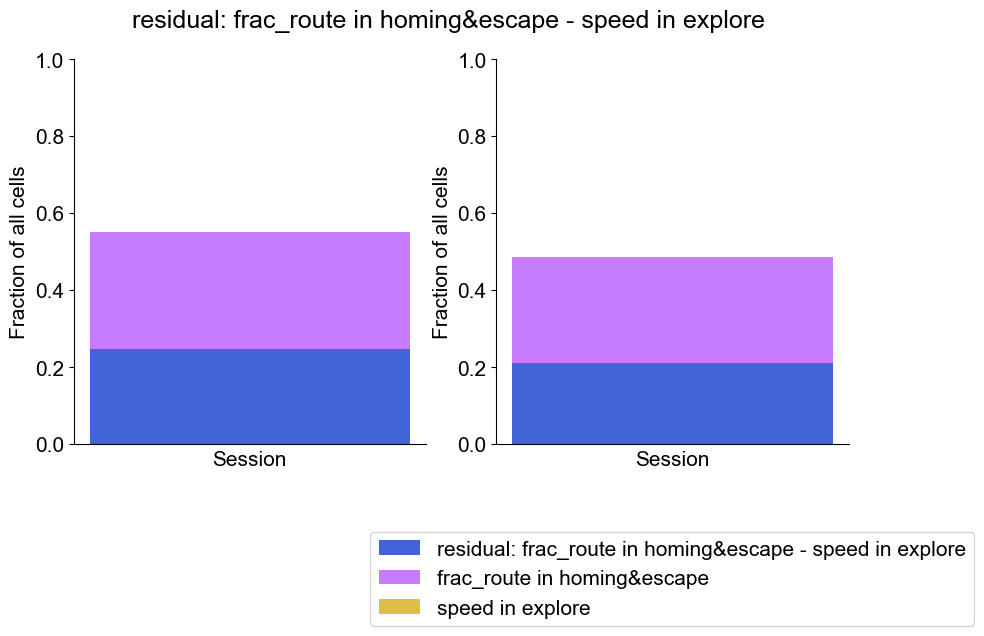

In [183]:
labels = ['sig. ' + var[1].split(" in ")[0], 'not sig. ' + var[1].split(" in ")[0], 'sig. ' + var[2].split(" in ")[0]]
tot_cond = len(fraction_sig_sesh_res[var[0]])
cond_names = list(fraction_sig_sesh_res[var[0]].keys())
fig, ax = plt.subplots(1, tot_cond, figsize=(5*tot_cond, 5))

for c in range(tot_cond): # iterate conditions
    # make a stacked bar plot with the three categories (sig_var1, sig_var1_nores, sig_var2) in different colors
    for s in range(len(experiments_objects)): # iterate sessions
        bottom = 0
        for i in range(len(var)): # iterate variables
            ax[c].bar(s, fraction_sig_sesh_res[var[i]][cond_names[c]][s], 
                bottom=bottom, color=colors[i], label=var[i] if s == 0 else "")
            bottom += fraction_sig_sesh_res[var[i]][cond_names[c]][s]
    ax[c].set_ylabel('Fraction of all cells')
    ax[c].set_xticks([])
    ax[c].set_xlabel('Session')
    ax[c].spines['top'].set_visible(False)
    ax[c].spines['right'].set_visible(False)
    ax[c].set_ylim(0, 1)
fig.suptitle(tuning)
ax[1].legend(bbox_to_anchor=(0.5, -.2), loc='upper center')

In [ ]:
"""Overview plot across sessions as a scatter plot"""
fig, ax = plt.subplots(1, 1, figsize=(len(fraction_sig_session), 5))
# make a matrix of the fraction of significant cells for each condition across sessions
fraction_sig_session_matrix = np.full((len(experiments_objects), len(fraction_sig_session)), np.nan)

for c_idx, c in enumerate(list(fraction_sig_session.keys())):
    fraction_sig_session_matrix[:, c_idx] = fraction_sig_session[c]
    ax.scatter(np.full_like(fraction_sig_session_matrix[:, c_idx], c_idx), fraction_sig_session_matrix[:, c_idx], color = colors[0])
    ax.hlines(np.mean(fraction_sig_session_matrix[:, c_idx]), c_idx - 0.2, c_idx + 0.2, color=colors[0], linewidth=2)
ax.set_xticks(np.arange(len(fraction_sig_session)))
ax.set_xticklabels(list(fraction_sig_session.keys()), rotation=45)
ax.set_ylabel('Fraction of all cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)
    # ax.set_title(tuning)
ax.plot(fraction_sig_session_matrix.T, color = 'lightgrey', alpha = 0.5)

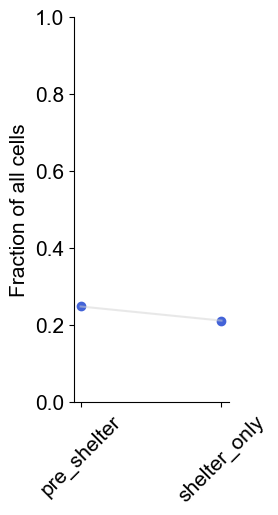

In [185]:
"""Overview plot across sessions as a scatter plot
Only plotting the ones tuned to var[1] that are still tuned after removing var[2]"""
tot_cond = len(fraction_sig_sesh_res[var[0]])
fraction_sig_sesh_res_matrix = np.full((len(experiments_objects), tot_cond), np.nan)
fig, ax = plt.subplots(1, 1, figsize=(tot_cond,5))
for c in range(tot_cond):
    fraction_sig_sesh_res_matrix[:, c] = fraction_sig_sesh_res[var[0]][cond_names[c]]
    ax.scatter(np.full_like(fraction_sig_sesh_res_matrix[:, c], c), fraction_sig_sesh_res_matrix[:, c], color = colors[0])
    ax.hlines(np.mean(fraction_sig_sesh_res_matrix[:, c]), c - 0.2, c + 0.2, color=colors[0], linewidth=2)
ax.set_xticks(np.arange(tot_cond))
ax.set_xticklabels(list(fraction_sig_sesh_res[var[0]].keys()), rotation=45)
ax.set_ylabel('Fraction of all cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)
title = tuning.split("residual: ")[1].split(" - ")[0] + "\n - " + tuning.split(" - ")[1]
    # ax.set_title(title)
ax.plot(fraction_sig_sesh_res_matrix.T, color = 'lightgrey', alpha = 0.5)

In [ ]:
"""Fraction of cells still tuned to frac_route after removing speed, bird_dit_shelter, hdir and 2D position"""

from pathlib import Path


var = ["frac_route in homing&escape", 
       "residual: frac_route in homing&escape = speed in explore", 
       "residual: frac_route in homing&escape = bird_dist_shelter in explore", 
       "residual: frac_route in homing&escape = 2D_position in explore"]
frac_remaining_sig = {}
for i, e in enumerate(experiments_objects[:2]):
    session = Process(e).load_session()
    data_path = os.path.join(session['base_path'], session['processed_path'], "models", "escape_tuning")
    sig = {v: [] for v in var}
    for v in var:
        computeET = ComputeEscapeTuning(tuning = v, session=session, settings=Settings_ae, aefizz=None)

        if computeET.do_analysis:
            print("analysis not done yet for this session {0} for variable {1}! Sad".format(session['name'], v))

            continue
        if computeET.database[computeET.database["name"] == computeET.hexaname]["insufficient_data"].values[0]:
            print("insufficient data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
            continue

        print("loading data for session {} with hexaname {}".format(session['name'], computeET.hexaname))
        data = computeET.load_results()
        shift0 = int(np.shape(data['y_fitted_shift'])[0] / 2)
        real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                                    shifted_matrix=data['fr_shift'], 
                                                    shift0=int(np.shape(data['fr_shift'])[0] / 2), 
                                                    neural_matrix=data['neural_matrix'], 
                                                    condition=data['condition_vector'])
        sig_escape = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
        sig[v] = sig_escape

    sig_remaining_sig = sig[var[0]] & sig[var[1]] & sig[var[2]] & sig[var[3]]

    # load hdir
    path = os.path.join(session['base_path'], session['processed_path'], "cells")
    cluster_Ids = np.load(str(os.path.join(session["base_path"], session["processed_path"]) + "/" + "good_cluster_Ids__bc.npy"))    
    hdir_path = list(Path(path).glob("*_hdir_cells.npy"))[0]
    hdir_cells = np.load(hdir_path)
    hdir = np.full(len(cluster_Ids), False)
    for hc in hdir_cells:
        hdir[cluster_Ids == hc] = True

    for c_idx, c in enumerate(data["all_conditions"]):
        sig_this_c = sig_remaining_sig[c_idx,:] & ~hdir
        frac_sig = np.sum(sig_this_c) / sig_remaining_sig.shape[1]
        if np.isnan(real_stat[c_idx,:]).all():
            frac_sig = np.nan
        if c in frac_remaining_sig.keys():
            frac_remaining_sig[c][i] = frac_sig
        else:
            frac_remaining_sig[c] = np.full((len(experiments_objects)), np.nan)
            frac_remaining_sig[c][i] = frac_sig


SyntaxError: invalid syntax (849794601.py, line 50)

In [ ]:
"""Overview plot across sessions as a scatter plot"""
fig, ax = plt.subplots(1, 1, figsize=(len(frac_remaining_sig), 5))
# make a matrix of the fraction of significant cells for each condition across sessions
fraction_sig_session_matrix = np.full((len(experiments_objects), len(frac_remaining_sig)), np.nan)

for c_idx, c in enumerate(list(frac_remaining_sig.keys())):
    fraction_sig_session_matrix[:, c_idx] = frac_remaining_sig[c]
    ax.scatter(np.full_like(fraction_sig_session_matrix[:, c_idx], c_idx), fraction_sig_session_matrix[:, c_idx], color = colors[0])
    ax.hlines(np.mean(fraction_sig_session_matrix[:, c_idx]), c_idx - 0.2, c_idx + 0.2, color=colors[0], linewidth=2)
ax.set_xticks(np.arange(len(frac_remaining_sig)))
ax.set_xticklabels(list(frac_remaining_sig.keys()), rotation=45)
ax.set_ylabel('Fraction of all cells')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)
    # ax.set_title(tuning)
ax.plot(fraction_sig_session_matrix.T, color = 'lightgrey', alpha = 0.5)